# K-Nearest-Neighbors

👇 `data` klasöründe bulunan `houses_clean.csv` dataset'ini yükleyin  
Veya doğrudan bu URL'den yükleyebilirsiniz: [https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv).  

Dataset açıklaması dataset-description.md dosyasında bulunabilir.

In [1]:
import pandas as pd

# Veri setini yükleyelim
df = pd.read_csv('data/houses_clean.csv')

# Hedef değişken (y) ve özellikler (X) ayrımı
# SalePrice tahmin etmek istediğimiz hedef sütun
y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

# Verinin ilk 5 satırına bakalım
df.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
0,0.380070,0.375,0.333333,0.500,1,208500
1,-0.312090,0.375,0.333333,0.875,1,181500
2,0.497489,0.375,0.333333,0.500,1,223500
3,0.390885,0.375,0.333333,0.500,1,140000
4,1.134029,0.500,0.333333,0.500,1,250000


💡 Çoğu özellik zaten önceden işlenmiştir (normalizasyonla ölçeklendirilmiştir), tıpkı Veri Hazırlama gününde yaptığınız gibi  

💡 Bir özellik olan `GrLiveArea` normalleştirilmemiştir. Daha sonra normalizasyonunun model performansımız üzerindeki etkisini görmek için bu şekilde tutuyoruz  

👇 Bunu tanımlayıcı istatistiklerle kolayca görebilirsiniz, min ve max değerlerine bakın

In [2]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


# Varsayılan KNN

🎯 Görev, tüm özelliklerle evlerin fiyatını (`SalePrice`) tahmin etmektir.

👇 Böyle bir görevde varsayılan [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)'ı değerlendirmek için çapraz doğrulama kullanın.  
❓ `SalePrice`'taki varyansın özellikler tarafından açıklanan oranı nedir?  
Cevabınızı `base_knn_score` adlı bir değişkende saklayın.

<details>
<summary> 💡 İpucu </summary>
    <br>
    ℹ️ Bağımlı değişkendeki varyansın bağımsız değişkenler tarafından açıklanan oranı R2 skoru'dur.
</details>

In [3]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# Modeli tanımlayalım (varsayılan ayarlarla)
knn_model = KNeighborsRegressor()

# 5 katlı çapraz doğrulama ile R2 skorlarını hesaplayalım
cv_scores = cross_val_score(knn_model, X, y, cv=5)

# Skorların ortalamasını alıp değişkene kaydedelim
base_knn_score = cv_scores.mean()

print(f"Varsayılan KNN R2 Skoru: {base_knn_score}")

Varsayılan KNN R2 Skoru: 0.608370347216843


### 🧪 Kodunuzu kontrol edin

In [4]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_default_score.py::TestDefault_score::test_score PASSED              [100%]

============================== 1 passed in 0.17s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



# Ölçek duyarlılığı

KNN'ler ve mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlı olabilir. 

👇 Özellik kümesini **tam ortak aralık** içinde yeniden ölçeklendirin ve `X_rescaled` adlı bir değişken altında kaydedin  
Ardından, yeniden ölçeklendirilmiş özellikler üzerinde bir modeli değerlendirin ve skorunu `rescaled_score` değişken adı altında kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
`MinMaxScaler()`

Sadece `GrLiveArea`'nın normalleştirilmesi gerekmesine rağmen, tüm özelliklerinizde MinMaxScaler kullanmak sorun değil  
    
Gerçekten de, Min-Max Ölçeklendirme [idempotent](https://en.wikipedia.org/wiki/Idempotence) bir dönüşümdür: eğer $X_{max}=1$ ve $X_{min}=0$ ise, o zaman $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>

In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. MinMaxScaler nesnesini oluşturalım
scaler = MinMaxScaler()

# 2. Özelliklerimizi (X) 0 ile 1 arasına ölçeklendirelim
X_rescaled = scaler.fit_transform(X)

# 3. Aynı KNN modelini ölçeklendirilmiş veriyle tekrar değerlendirelim
rescaled_cv_scores = cross_val_score(knn_model, X_rescaled, y, cv=5)
rescaled_score = rescaled_cv_scores.mean()

print(f"Ölçeklendirilmiş KNN R2 Skoru: {rescaled_score}")

Ölçeklendirilmiş KNN R2 Skoru: 0.649893812648999


👉 R2 skoru artmış olmalı!

💡 Mesafe tabanlı algoritmaları modellerken özelliklerin tam ortak aralıkta olması tercih edilir.  
Ancak, her zaman daha iyi bir skor garanti etmez.  
Bu bir deneme yanılma sürecidir.

### 🧪 Kodunuzu kontrol edin

In [6]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_scale_sensitivity.py::TestScale_sensitivity::test_rescaled_features PASSED [ 50%]
test_scale_sensitivity.py::TestScale_sensitivity::test_score_inscrease PASSED [100%]

============================== 2 passed in 0.24s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



# $k$ Optimizasyonu

👇 Yeniden ölçeklendirilmiş özellikler üzerinde bir KNNRegressor'ın K parametresini (`n_neighbors` parametresini kullanarak) ince ayarlayın. K 1'den 25'e kadar arttıkça skorun evrimini çizin.

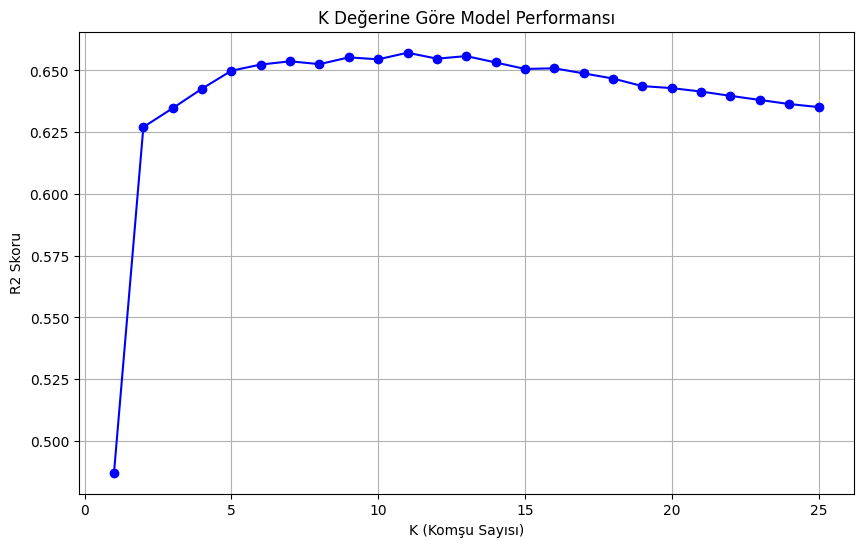

In [7]:
import matplotlib.pyplot as plt

# 1'den 25'e kadar k değerlerini test edelim
k_values = range(1, 26)
scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_rescaled, y, cv=5)
    scores.append(cv_scores.mean())

# Skorların değişimini grafiğe dökelim
plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', linestyle='-', color='blue')
plt.title('K Değerine Göre Model Performansı')
plt.xlabel('K (Komşu Sayısı)')
plt.ylabel('R2 Skoru')
plt.grid(True)
plt.show()

❓ K'nın hangi değeri en iyi performansı üretir? Cevabınızı `best_k` değişken adı altında kaydedin.

In [8]:
# En yüksek skoru veren k değerini bulalım
best_k = k_values[scores.index(max(scores))]

print(f"En iyi performansı veren K değeri: {best_k}")
print(f"Bu K değeri ile ulaşılan en iyi skor: {max(scores)}")

En iyi performansı veren K değeri: 11
Bu K değeri ile ulaşılan en iyi skor: 0.6571704043326225


<details>
<summary> 👉 Çözüm 👈</summary>
    
Grafiğinize bakarak, skorun k = 5 civarında artmayı durdurduğunu ve maksimum skorun k = 11 için ulaşıldığını görmelisiniz.

</details>

❓ $k$ < 5 değerleri için modelin kötü performansını nasıl yorumluyorsunuz?

<details>
<summary> 👉 Çözüm 👈</summary>
    
K çok küçük olduğunda, model eğitim kümesine aşırı uyum gösterme eğiliminde olacaktır. İyi genelleştirebilmek için çok az noktaya odaklanacaktır. K'yı artırmak modele tahminlerini dayandıracağı daha fazla örnek verecektir.

</details>

### 🧪 Kodunuzu kontrol edin

In [9]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_K_around_10 PASSED        [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



# KNN'de Aşırı Uyum

💡 KNN'lerin K parametresi çok küçük olduğunda, eğitim kümesine aşırı uyum gösterme ve iyi genelleştirememe riski vardır. 

👇 K=2 parametreli bir KNN'in öğrenme eğrilerini çizin.

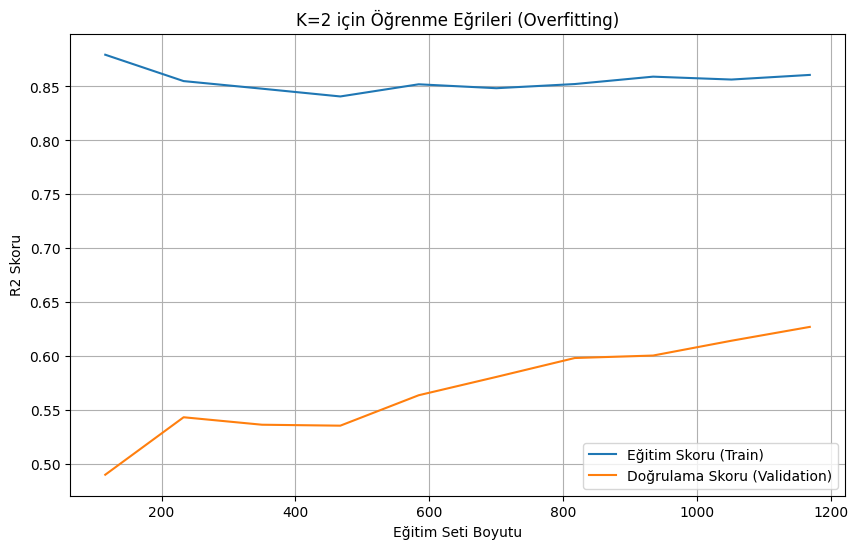

In [10]:
from sklearn.model_selection import learning_curve
import numpy as np

# K=2 (küçük K) için öğrenme eğrilerini hesaplayalım
train_sizes, train_scores, test_scores = learning_curve(
    KNeighborsRegressor(n_neighbors=2), X_rescaled, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2'
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Eğitim Skoru (Train)')
plt.plot(train_sizes, test_scores_mean, label='Doğrulama Skoru (Validation)')
plt.title('K=2 için Öğrenme Eğrileri (Overfitting)')
plt.xlabel('Eğitim Seti Boyutu')
plt.ylabel('R2 Skoru')
plt.legend()
plt.grid(True)
plt.show()

👉 Yüksek eğitim skoru ama düşük test skoru gözlemlemelisiniz. ⚠️ Aşırı uyum uyarısı ⚠️ Bu çok düşük K parametresinden kaynaklanır.

# İdeal K

👇 Bu sefer, "$k$ Optimizasyonu" bölümünde bulduğunuz ideal K değeri için öğrenme eğrilerini çizin.

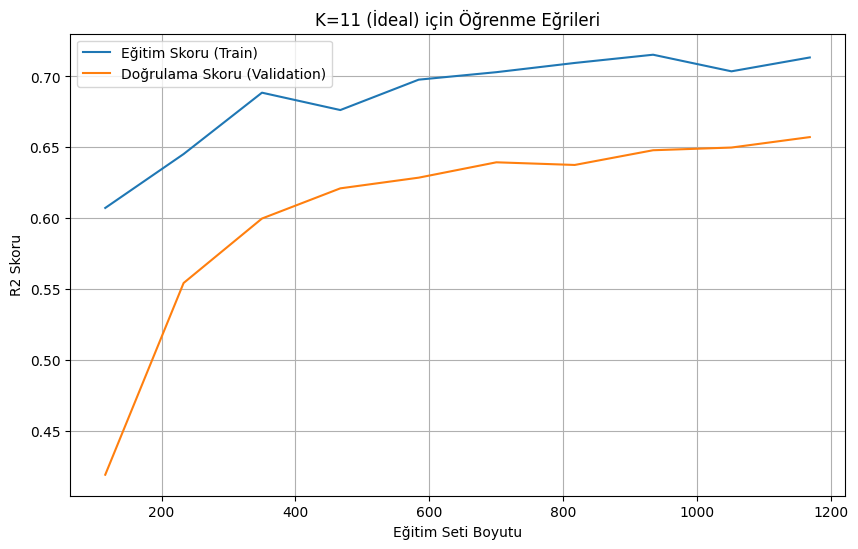

In [11]:
# İdeal K için öğrenme eğrileri
train_sizes, train_scores, test_scores = learning_curve(
    KNeighborsRegressor(n_neighbors=best_k), X_rescaled, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2'
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Eğitim Skoru (Train)')
plt.plot(train_sizes, test_scores_mean, label='Doğrulama Skoru (Validation)')
plt.title(f'K={best_k} (İdeal) için Öğrenme Eğrileri')
plt.xlabel('Eğitim Seti Boyutu')
plt.ylabel('R2 Skoru')
plt.legend()
plt.grid(True)
plt.show();

👉 Eğriler yakınsamaya yakın olmalı, bu da modelin daha az aşırı uyum gösterdiğini ve daha iyi genelleştirdiğini gösterir.

💡 KNN modelleriyle modelleme yaparken hatırlanması gereken iki temel unsur vardır:  
    1. Mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlıdır  
    2. K ayarlanmalıdır: performans, genelleştirme ve aşırı uyum arasındaki dengeyi kontrol eder

❓ Optimize edilmiş KNN modelinin gerçek fiyat ile tahmin edilen fiyat arasındaki ortalama fark nedir? Cevabınızı hesaplayın ve `price_error` değişken adı altında kaydedin

<details>
<summary> 💡 İpucu </summary>
    
Hesaplamanız gereken metrik **Negatif Ortalama Mutlak Hata (MAE)**'dır.

</details>

In [12]:
from sklearn.model_selection import cross_val_score

# 'neg_mean_absolute_error' metriği, tahmin edilen ve gerçek fiyatlar arasındaki mutlak farkı hesaplar.
# Scikit-learn bu değeri negatif döndürdüğü için başına '-' koyarak pozitif gerçek hata değerini elde ederiz.

mae_scores = cross_val_score(
    KNeighborsRegressor(n_neighbors=best_k), 
    X_rescaled, 
    y, 
    cv=5, 
    scoring='neg_mean_absolute_error'
)

# Ortalama hatayı hesaplayıp price_error değişkenine kaydedelim
price_error = -mae_scores.mean()

print(f"Optimize edilmiş KNN modelinin ortalama fiyat hatası: {price_error:.2f} $")

Optimize edilmiş KNN modelinin ortalama fiyat hatası: 30823.53 $


### 🧪 Kodunuzu kontrol edin

In [13]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_price_error.py::TestPrice_error::test_price_error_range PASSED      [100%]

============================== 1 passed in 0.24s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



# Model Seçimi

❓ Ev fiyatlarını tahmin etme görevini gerçekleştirmek için bu iki modelden hangisini seçersiniz:
- Az önce ayarladığınız KNN modeli
- Bir Linear Regression modeli

Cevabınızı "KNN" veya "LinearReg" olarak `best_model` değişken adı altında string olarak kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
Hangisini seçeceğinize karar vermek için, aynı görev üzerinde bir Linear Regression skorunu değerlendirmeniz ve KNN'in skoruyla karşılaştırmanız gerekecek. Aynı metrikleri karşılaştırdığınızdan emin olun!!

</details>

In [14]:
from sklearn.linear_model import LinearRegression

# 1. Linear Regression modelini tanımlayalım ve çapraz doğrulama ile skorunu hesaplayalım
lin_reg = LinearRegression()
lin_reg_scores = cross_val_score(lin_reg, X_rescaled, y, cv=5)
lin_reg_score = lin_reg_scores.mean()

print(f"Linear Regression R2 Skoru: {lin_reg_score:.4f}")
print(f"KNN (k={best_k}) R2 Skoru: {rescaled_score:.4f}")

# 2. İki skoru karşılaştırarak en iyi modeli seçelim
# Notebook'taki ipucuna göre KNN'in daha iyi performans göstermesi beklenmektedir
if rescaled_score > lin_reg_score:
    best_model = "KNN"
else:
    best_model = "LinearReg"

print(f"Seçilen en iyi model: {best_model}")

Linear Regression R2 Skoru: 0.5945
KNN (k=11) R2 Skoru: 0.6499
Seçilen en iyi model: KNN


💡 Her iki modelin metriklerini karşılaştırdığınızda, KNN modeli Linear Regression'ı geçmelidir. Bu, verideki doğrusal olmayan kalıpları yakalama yeteneğinden kaynaklanabilir.

### 🧪 Kodunuzu kontrol edin

In [15]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/bariscan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/bariscan/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.03s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



# 🏁